In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

fichiers = files.upload()

noms_requis = [
    "resultats_1B_100_session_1.npz",
    "resultats_1B_100_session_2.npz",
    "resultats_1B_50.npz"
]

for nom in noms_requis:
    if nom not in fichiers:
        raise FileNotFoundError(
            f"Le fichier {nom} n'a pas été chargé."
        )

essais = [
    np.load(
        "resultats_1B_100_session_1.npz",
        allow_pickle=False
    ),
    np.load(
        "resultats_1B_100_session_2.npz",
        allow_pickle=False
    ),
    np.load(
        "resultats_1B_50.npz",
        allow_pickle=False
    )
]

print("Les trois campagnes ont été chargées.")

Saving resultats_1B_50.npz to resultats_1B_50.npz
Saving resultats_1B_100_session_2.npz to resultats_1B_100_session_2.npz
Saving resultats_1B_100_session_1.npz to resultats_1B_100_session_1.npz
Les trois campagnes ont été chargées.


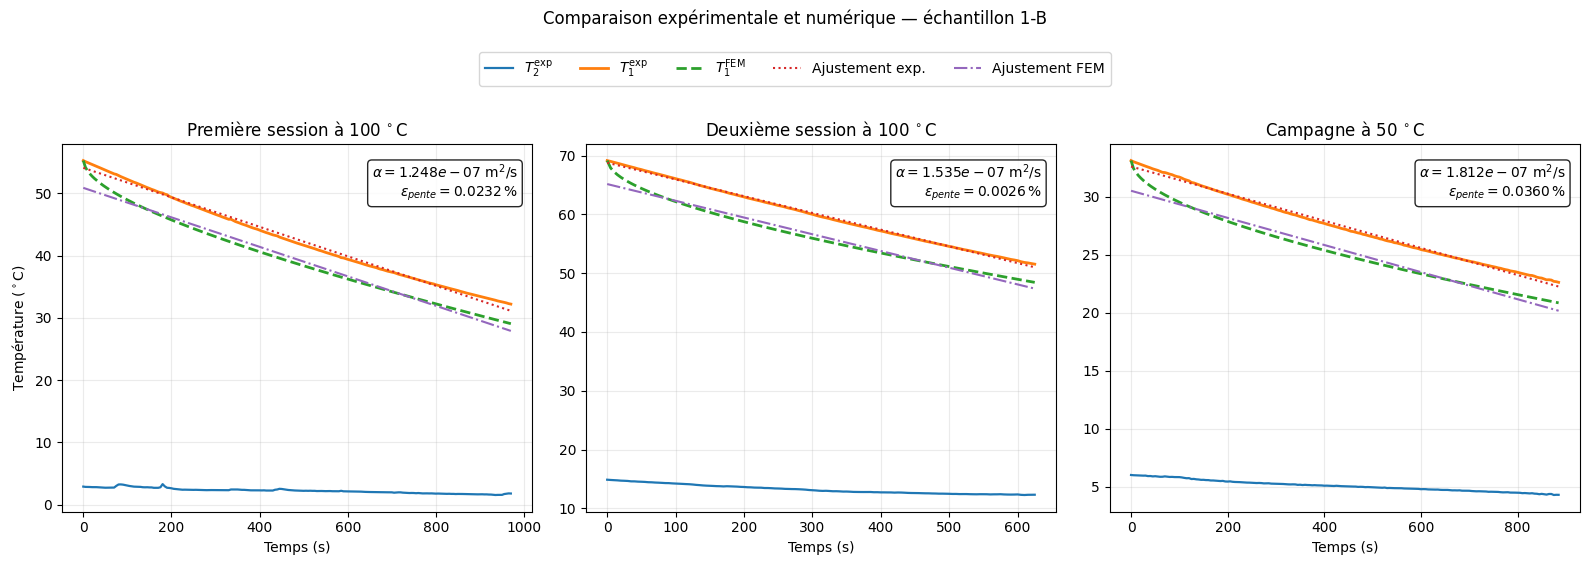

In [ ]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

titres = [
    r"Première session à $100\,^\circ$C",
    r"Deuxième session à $100\,^\circ$C",
    r"Campagne à $50\,^\circ$C"
]

for ax, essai, titre in zip(axes, essais, titres):

    tau = essai["tau"]
    T1_exp = essai["T1_exp"]
    T2_exp = essai["T2_exp"]
    T1_fem = essai["T1_fem"]

    pente_exp = float(essai["pente_exp"])
    pente_fem = float(essai["pente_fem"])

    fit_exp = (
        pente_exp * tau
        + T1_exp.mean()
        - pente_exp * tau.mean()
    )

    fit_fem = (
        pente_fem * tau
        + T1_fem.mean()
        - pente_fem * tau.mean()
    )

    ax.plot(
        tau,
        T2_exp,
        linewidth=1.6,
        label=r"$T_2^{\mathrm{exp}}$"
    )

    ax.plot(
        tau,
        T1_exp,
        linewidth=2.0,
        label=r"$T_1^{\mathrm{exp}}$"
    )

    ax.plot(
        tau,
        T1_fem,
        linestyle="--",
        linewidth=2.0,
        label=r"$T_1^{\mathrm{FEM}}$"
    )

    ax.plot(
        tau,
        fit_exp,
        linestyle=":",
        linewidth=1.5,
        label="Ajustement exp."
    )

    ax.plot(
        tau,
        fit_fem,
        linestyle="-.",
        linewidth=1.5,
        label="Ajustement FEM"
    )

    alpha = float(essai["alpha"])
    erreur = float(essai["erreur_pente_percent"])

    ax.set_title(titre)
    ax.set_xlabel("Temps (s)")
    ax.grid(alpha=0.25)

    ax.text(
        0.97,
        0.95,
        (
            rf"$\alpha={alpha:.3e}\ \mathrm{{m^2/s}}$"
            "\n"
            rf"$\varepsilon_{{pente}}={erreur:.4f}\,\%$"
        ),
        transform=ax.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85
        }
    )

axes[0].set_ylabel(
    r"Température ($^\circ$C)"
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.05)
)

fig.suptitle(
    "Comparaison expérimentale et numérique — échantillon 1-B",
    y=1.12
)

fig.tight_layout()

chemin_pdf = "/content/ajustements_temperature_1B.pdf"
chemin_png = "/content/ajustements_temperature_1B.png"

fig.savefig(
    chemin_pdf,
    bbox_inches="tight",
    dpi=300
)

fig.savefig(
    chemin_png,
    bbox_inches="tight",
    dpi=300
)

plt.show()